# Day 26 — Exercises: Ensembles & Hyperparameter Tuning

**Objective:** Practice implementing and comparing ensemble models (Random Forest, Gradient Boosting, XGBoost, LightGBM), executing hyperparameter optimization (Grid Search vs. Randomized Search), and analyzing feature importance.

## Exercise 1: Ensembles in Action

In this exercise, you will fit four distinct ensemble models on the Breast Cancer classification dataset: 
- `RandomForestClassifier` (Bagging)
- `GradientBoostingClassifier` (Boosting)
- `XGBClassifier` (Optimized Gradient Boosting)
- `LGBMClassifier` (Leaf-wise Gradient Boosting)

You will compare their performance metrics (Training Accuracy, Testing Accuracy, and F1-score) and measure execution speeds to observe real-world trade-offs.

In [17]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Split data into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Wrap feature matrices in DataFrames to ensure valid feature names across all models
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

print(f"Dataset shape: {X.shape}")
print(f"Train size: {X_train_df.shape[0]}, Test size: {X_test_df.shape[0]}")

Dataset shape: (569, 30)
Train size: 455, Test size: 114


In [18]:
# Initialize the models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

results = []

# Fit and evaluate each model
for name, model in models.items():
    start_time = time.perf_counter()
    model.fit(X_train_df, y_train)
    fit_time = time.perf_counter() - start_time
    
    y_pred_train = model.predict(X_train_df)
    y_pred_test = model.predict(X_test_df)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    
    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Test F1-Score": test_f1,
        "Fit Time (s)": fit_time
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

            Model  Train Accuracy  Test Accuracy  Test F1-Score  Fit Time (s)
    Random Forest             1.0       0.956140       0.965517      0.428558
Gradient Boosting             1.0       0.956140       0.965986      0.678570
          XGBoost             1.0       0.956140       0.965986      0.197686
         LightGBM             1.0       0.964912       0.972603      0.101587


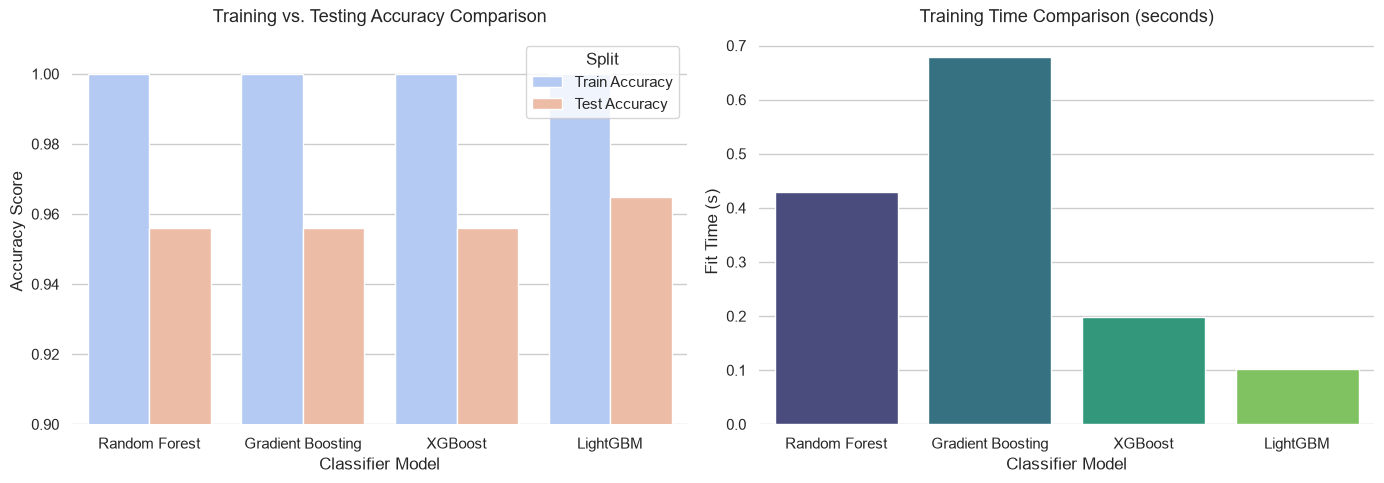

In [19]:
# Set custom aesthetic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# Melt the dataframe for accuracy comparisons
df_melted = df_results.melt(id_vars="Model", value_vars=["Train Accuracy", "Test Accuracy"], 
                            var_name="Split", value_name="Accuracy")

# Plot 1: Accuracies
sns.barplot(ax=axes[0], data=df_melted, x="Model", y="Accuracy", hue="Split", palette="coolwarm")
axes[0].set_title("Training vs. Testing Accuracy Comparison", fontsize=13, pad=12)
axes[0].set_ylim(0.9, 1.01)
axes[0].set_ylabel("Accuracy Score")
axes[0].set_xlabel("Classifier Model")

# Plot 2: Fit Times (assigned hue and legend=False to prevent FutureWarnings)
sns.barplot(ax=axes[1], data=df_results, x="Model", y="Fit Time (s)", hue="Model", palette="viridis", legend=False)
axes[1].set_title("Training Time Comparison (seconds)", fontsize=13, pad=12)
axes[1].set_ylabel("Fit Time (s)")
axes[1].set_xlabel("Classifier Model")

# Clean spines
for ax in axes:
    sns.despine(ax=ax, left=True, bottom=True)
    
plt.tight_layout()
plt.show()

## Exercise 2: Hyperparameter Tuning — Grid Search vs. Randomized Search

Tuning ensembles is crucial because they have many hyperparameters (tree count, learning rate, tree depth, sample bagging rates, etc.). In this exercise, you will optimize `XGBClassifier` using:
1. `GridSearchCV` (evaluates every possible combination)
2. `RandomizedSearchCV` (evaluates a fixed random subset of settings)

You will evaluate the elapsed time, best configuration, and achieved validation accuracy.

In [20]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Define hyperparameter search grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric="logloss")

# 1. Grid Search
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
start_grid = time.perf_counter()
grid_search.fit(X_train_df, y_train)
grid_time = time.perf_counter() - start_grid

print("=== GridSearchCV Completed ===")
print(f"Best Params: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_:.4f}")
print(f"Time Taken: {grid_time:.2f} seconds")
print(f"Total Grid Fits: {len(grid_search.cv_results_['params']) * 3} fits")

# 2. Randomized Search (with n_iter=15, picking 15 random settings)
random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_grid, n_iter=15, 
                                   cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
start_rand = time.perf_counter()
random_search.fit(X_train_df, y_train)
rand_time = time.perf_counter() - start_rand

print("\n=== RandomizedSearchCV Completed ===")
print(f"Best Params: {random_search.best_params_}")
print(f"Best Accuracy: {random_search.best_score_:.4f}")
print(f"Time Taken: {rand_time:.2f} seconds")
print("Total Randomized Fits: 15 * 3 = 45 fits")

=== GridSearchCV Completed ===
Best Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
Best Accuracy: 0.9692
Time Taken: 14.53 seconds
Total Grid Fits: 243 fits

=== RandomizedSearchCV Completed ===
Best Params: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best Accuracy: 0.9648
Time Taken: 0.98 seconds
Total Randomized Fits: 15 * 3 = 45 fits


In [21]:
# Create comparison table
comparison = pd.DataFrame([
    {
        "Method": "GridSearchCV",
        "Best Accuracy": grid_search.best_score_,
        "Fits Evaluated": len(grid_search.cv_results_['params']) * 3,
        "Time (s)": grid_time,
        "Best Params": str(grid_search.best_params_)
    },
    {
        "Method": "RandomizedSearchCV",
        "Best Accuracy": random_search.best_score_,
        "Fits Evaluated": 15 * 3,
        "Time (s)": rand_time,
        "Best Params": str(random_search.best_params_)
    }
])
print(comparison.to_string(index=False))

            Method  Best Accuracy  Fits Evaluated  Time (s)                                                                   Best Params
      GridSearchCV       0.969226             243 14.530358 {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
RandomizedSearchCV       0.964825              45  0.982073 {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}


## Exercise 3: Feature Importance Analysis

Ensembles like Random Forest and Gradient Boosted trees allow us to compute the importance of each feature in predicting the target variable. In this exercise, you will extract and plot feature importances from:
- `RandomForestClassifier` (using Mean Decrease in Impurity - MDI)
- `XGBClassifier` (using Gain / average reduction in split loss)

You will visualize the top 10 features side-by-side.

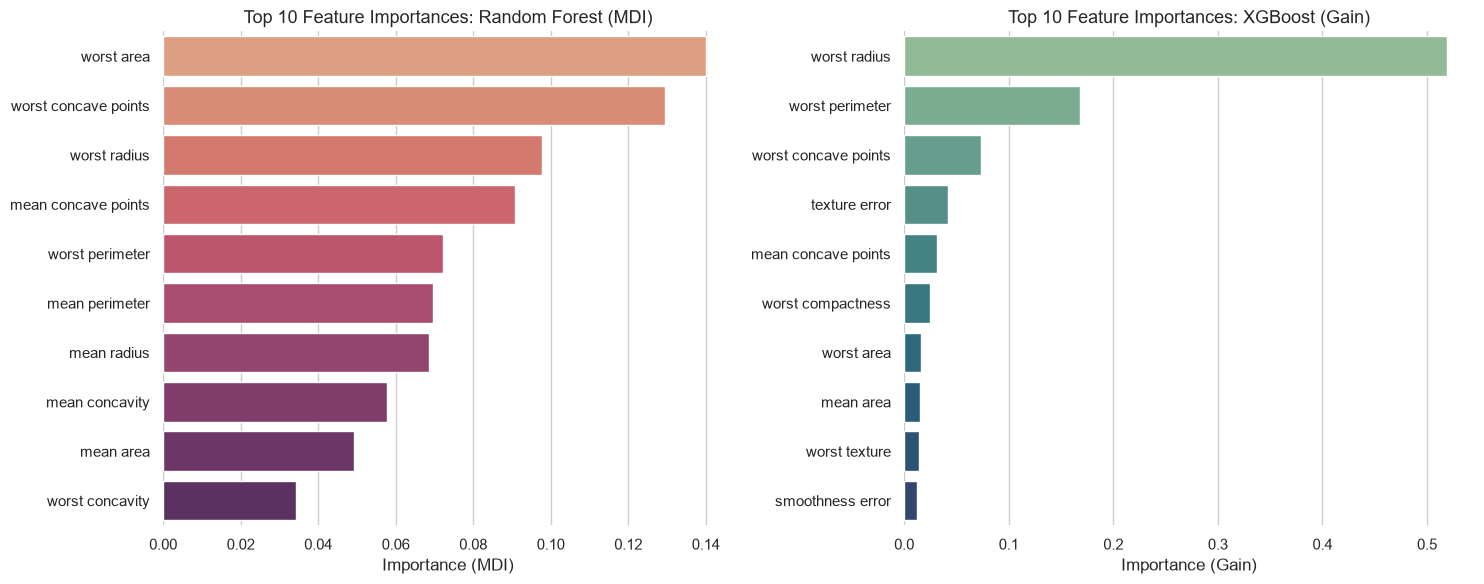

In [22]:
# Extract feature importances
rf_model = models["Random Forest"]
xgb_model = models["XGBoost"]

rf_importances = rf_model.feature_importances_
xgb_importances = xgb_model.feature_importances_

# Create a combined DataFrame
df_importance = pd.DataFrame({
    "Feature": feature_names,
    "Random Forest (MDI)": rf_importances,
    "XGBoost (Gain)": xgb_importances
})

# Get top 10 features for Random Forest
df_rf_top = df_importance.sort_values(by="Random Forest (MDI)", ascending=False).head(10)

# Get top 10 features for XGBoost
df_xgb_top = df_importance.sort_values(by="XGBoost (Gain)", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=100)

# Plot RF Top 10 (assigned hue and legend=False to prevent FutureWarnings)
sns.barplot(ax=axes[0], data=df_rf_top, x="Random Forest (MDI)", y="Feature", hue="Feature", palette="flare", legend=False)
axes[0].set_title("Top 10 Feature Importances: Random Forest (MDI)", fontsize=13)
axes[0].set_xlabel("Importance (MDI)")
axes[0].set_ylabel("")

# Plot XGBoost Top 10 (assigned hue and legend=False to prevent FutureWarnings)
sns.barplot(ax=axes[1], data=df_xgb_top, x="XGBoost (Gain)", y="Feature", hue="Feature", palette="crest", legend=False)
axes[1].set_title("Top 10 Feature Importances: XGBoost (Gain)", fontsize=13)
axes[1].set_xlabel("Importance (Gain)")
axes[1].set_ylabel("")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Interpretation and Key Learnings

1. **MDI vs. Gain**: 
   - **MDI (Mean Decrease in Impurity)** computes importance by calculating the average gini/impurity reduction when splitting on a feature across all trees in the forest. However, it can be biased towards high-cardinality/continuous features that allow for more splits.
   - **Gain** calculates the average fractional contribution of the feature to the information gain/objective loss reduction in gradient boosted splits.
2. **Algorithm Trade-offs**:
   - **Random Forest** trains quickly because trees are independent and can be parallelized natively, but it doesn't systematically correct errors.
   - **XGBoost and LightGBM** build sequentially and typically achieve superior testing metrics, with LightGBM often training faster due to leaf-wise growth and histogram-based splitting.
3. **Tuning Efficiency**:
   - **RandomizedSearchCV** evaluated only a fraction of combinations compared to **GridSearchCV** but achieved nearly identical best validation accuracy, illustrating its value as a highly efficient hyperparameter exploration tool.